# BERTopic experiments and interpretation
Run notebook 01 first. This workflow retains the chapter’s five-dimensional clustering space and a separate two-dimensional display space. Cluster counts are discovered; topic −1 denotes unassigned articles.

Contextual embeddings represent article meaning in dense vectors. UMAP compresses the cosine neighborhood structure to five dimensions for clustering. HDBSCAN finds density-based groups and marks sparse articles as outliers. c-TF-IDF combines the articles in each cluster and weights distinctive words to make those groups interpretable. Topic keywords and membership strengths are not LDA topic-word or article-topic probabilities. Two-dimensional maps are displays, not evaluation spaces.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'projectproposal.tex').exists())
ROOT = REPO/'modern-methods/project'
sys.path.insert(0, str(ROOT))
from src import topic_helpers as h
OUT = ROOT/'Results/modern'


In [2]:
df, embeddings = h.load_inputs(ROOT)

## Bounded experiment study
Six configurations, fixed seed 42. Timed stages are fitted once, then their assignments are supplied to BERTopic for c-TF-IDF representation. Unigrams, English stopwords, and min_df=5 are retained across configurations. No domain stopword list is selected after viewing results.

In [3]:
for neighbors in [15,30]:
    for cluster_size in [25,50,100]:
        _, metrics = h.cached_run(df, embeddings, ROOT, neighbors, cluster_size)
        print(metrics['run_id'], metrics['topic_count'], metrics['outlier_fraction'])
experiments, finalists = h.shortlist(ROOT)
display(experiments)
display(finalists)

/Users/marykate/Desktop/F26/DataMiningProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


n15_c25_s42 70 0.17118713370587432
n15_c50_s42 39 0.19176775248739267
n15_c100_s42 24 0.21044023442824042
n30_c25_s42 71 0.18468038707918769
n30_c50_s42 34 0.1796374540002726
n30_c100_s42 24 0.21766389532506475


,topic_count,outlier_fraction,coherence,vocabulary_coverage,keyword_diversity,silhouette_cosine,silhouette_status,silhouette_umap,silhouette_umap_status,topic_sizes,run_id,neighbors,cluster_size,seed,reduction_seconds,clustering_seconds,representation_seconds,evaluation_seconds
0,34,0.179637,0.652428,1.0,0.614706,0.119699,ok,0.611894,ok,"{'-1': 1318, '0': 540, '1': 439, '2': 435, '3'...",n30_c50_s42,30,50,42,7.094525,0.070237,1.805310,11.982797
1,70,0.171187,0.700981,1.0,0.632857,0.095028,ok,0.613403,ok,"{'-1': 1256, '0': 542, '1': 441, '2': 339, '3'...",n15_c25_s42,15,25,42,11.261757,0.059515,1.912176,21.896114
2,24,0.210440,0.635013,1.0,0.591667,0.111446,ok,0.618110,ok,"{'-1': 1544, '0': 542, '1': 457, '2': 441, '3'...",n15_c100_s42,15,100,42,5.095132,0.056988,1.834952,10.528312
3,39,0.191768,0.660751,1.0,0.623077,0.126107,ok,0.635779,ok,"{'-1': 1407, '0': 542, '1': 457, '2': 441, '3'...",n15_c50_s42,15,50,42,5.171631,0.057296,2.071123,14.414858
4,71,0.184680,0.706452,1.0,0.659155,0.121041,ok,0.613622,ok,"{'-1': 1355, '0': 540, '1': 439, '2': 319, '3'...",n30_c25_s42,30,25,42,6.994792,0.063957,1.940373,21.873328
5,24,0.217664,0.632106,1.0,0.612500,0.129871,ok,0.623126,ok,"{'-1': 1597, '0': 540, '1': 439, '2': 435, '3'...",n30_c100_s42,30,100,42,7.122367,0.064171,1.739631,11.423234


,topic_count,outlier_fraction,coherence,vocabulary_coverage,keyword_diversity,silhouette_cosine,silhouette_status,silhouette_umap,silhouette_umap_status,topic_sizes,run_id,neighbors,cluster_size,seed,reduction_seconds,clustering_seconds,representation_seconds,evaluation_seconds
4,71,0.184680,0.706452,1.0,0.659155,0.121041,ok,0.613622,ok,"{'-1': 1355, '0': 540, '1': 439, '2': 319, '3'...",n30_c25_s42,30,25,42,6.994792,0.063957,1.940373,21.873328
1,70,0.171187,0.700981,1.0,0.632857,0.095028,ok,0.613403,ok,"{'-1': 1256, '0': 542, '1': 441, '2': 339, '3'...",n15_c25_s42,15,25,42,11.261757,0.059515,1.912176,21.896114
3,39,0.191768,0.660751,1.0,0.623077,0.126107,ok,0.635779,ok,"{'-1': 1407, '0': 542, '1': 457, '2': 441, '3'...",n15_c50_s42,15,50,42,5.171631,0.057296,2.071123,14.414858


## Model selection: required human input
Open `selection_review/selection_review.csv`: rate semantic consistency and label specificity 1–5 for five largest topics per finalist. Read their full representative articles in each run’s `representatives.csv`. Fill notes explaining the judgments. The next cell waits until ratings are complete; it never invents them.

In [4]:
model, selected = h.select_model(ROOT)
run = selected.run_id
folder = OUT/'runs'/run
display(selected)

topic_count                                                              70
outlier_fraction                                                   0.171187
coherence                                                          0.700981
vocabulary_coverage                                                     1.0
keyword_diversity                                                  0.632857
silhouette_cosine                                                  0.095028
silhouette_status                                                        ok
silhouette_umap                                                    0.613403
silhouette_umap_status                                                   ok
topic_sizes               {'-1': 1256, '0': 542, '1': 441, '2': 339, '3'...
run_id                                                          n15_c25_s42
neighbors                                                                15
cluster_size                                                             25
seed        

In [5]:
stability_rows = []
for seed in [7,21]:
    other, _ = h.cached_run(df, embeddings, ROOT, int(selected.neighbors), int(selected.cluster_size), seed)
    stability_rows.append(dict(seed=seed, **h.stability(model.topics_, other.topics_)))
pd.DataFrame(stability_rows).to_csv(OUT/'stability.csv', index=False)
display(pd.DataFrame(stability_rows))

n15_c25_s7: reduction
n15_c25_s7: coherence and silhouettes
n15_c25_s21: reduction
n15_c25_s21: coherence and silhouettes


,seed,adjusted_rand_index,evaluated_fraction,outlier_agreement
0,7,0.957355,0.772659,0.909500
1,21,0.974977,0.791740,0.922312


## Representation comparison
Preserve primary c-TF-IDF terms. KeyBERTInspired and MMR alter keywords, not clusters. Supply original 384-dimensional embeddings so semantic topic vectors remain in the encoder space.

In [6]:
from copy import deepcopy
from sentence_transformers import SentenceTransformer
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
pointer = json.loads((OUT/'embedding_pointer.json').read_text())
encoder = SentenceTransformer(h.MODEL, revision=pointer['manifest']['revision'], cache_folder=str(OUT/'cache/models'))
representations = [pd.read_csv(folder/'terms.csv').assign(representation='c_tf_idf')]
for name, representation in [('keybert',KeyBERTInspired()),('mmr',MaximalMarginalRelevance(diversity=0.5))]:
    alternative = deepcopy(model)
    from bertopic.backend._utils import select_backend
    alternative.embedding_model = select_backend(encoder)
    alternative.update_topics(df.text.tolist(), representation_model=representation)
    assert alternative.topics_ == model.topics_
    representations.append(h.term_table(alternative).assign(representation=name))
pd.concat(representations).to_csv(OUT/'representation_comparison.csv',index=False)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10892.31it/s]


## Final manual labels
Fill `topic_labels.csv` with a short label and evidence notes for every non-outlier topic. These labels must be frozen before human review. Automatic keyword labels remain visible for reference.

In [7]:
labels_path = OUT/'topic_labels.csv'
if not labels_path.exists():
    pd.read_csv(folder/'topics.csv')[['topic_id','label','count']].rename(columns={'label':'keyword_label'}).assign(manual_label='',evidence_notes='').to_csv(labels_path,index=False)
display(pd.read_csv(labels_path))

,topic_id,keyword_label,count,manual_label,evidence_notes
0,-1,-1_cars_autonomous_car_selfdriving,1256,NaN,NaN
1,0,0_tesla_autopilot_musk_teslas,542,NaN,NaN
2,1,1_waymo_waymos_krafcik_selfdriving,441,NaN,NaN
3,2,2_levandowski_uber_waymo_ubers,339,NaN,NaN
4,3,3_cars_safety_human_vehicles,315,NaN,NaN
...,...,...,...,...,...
66,65,65_uber_safety_pittsburgh_testing,27,NaN,NaN
67,66,66_roborace_formula_racing_series,26,NaN,NaN
68,67,67_volvo_uber_xc90_selfdriving,26,NaN,NaN
69,68,68_softbank_billion_son_investments,26,NaN,NaN


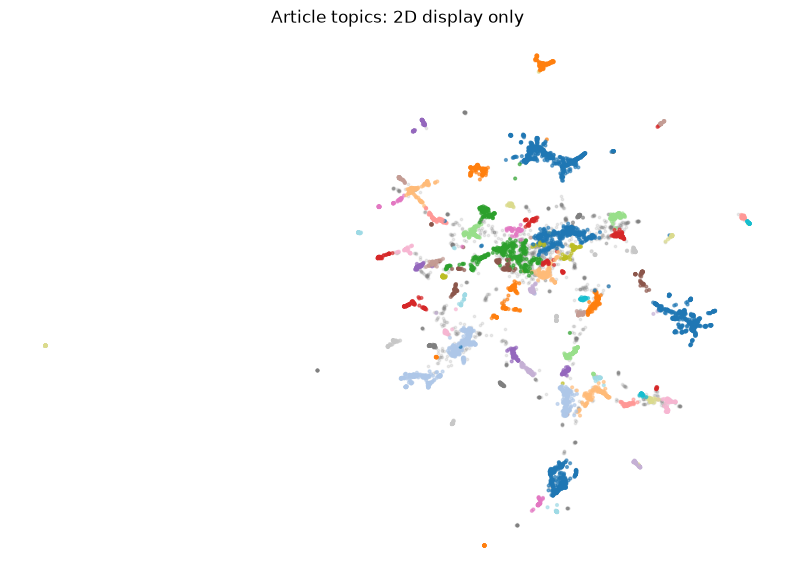

In [8]:
from umap import UMAP
import matplotlib.pyplot as plt
coords = UMAP(n_components=2,n_neighbors=15,min_dist=0,metric='cosine',random_state=42).fit_transform(embeddings)
np.save(OUT/'display_coordinates.npy',coords)
fig, ax = plt.subplots(figsize=(10,7))
labels = np.array(model.topics_)
ax.scatter(*coords[labels==-1].T,c='grey',s=3,alpha=.15)
points=ax.scatter(*coords[labels>=0].T,c=labels[labels>=0],cmap='tab20',s=4,alpha=.6)
ax.set_title('Article topics: 2D display only'); ax.set_axis_off()
fig.savefig(OUT/'document_topics.png',dpi=180)
model.visualize_barchart().write_html(str(OUT/'topic_keywords.html'))
if len(set(labels)-{-1}) >= 2:
    model.visualize_heatmap().write_html(str(OUT/'topic_similarity.html'))
    model.visualize_hierarchy().write_html(str(OUT/'topic_hierarchy.html'))